<a href="https://colab.research.google.com/github/ranel-star/PythonProject2/blob/main/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install dependencies as needed:
%pip install kagglehub[pandas-datasets]

In [ ]:
!pip install import-ipynb
import import_ipynb
import requests
import os

# 1. URL to the RAW version of the notebook on GitHub
github_url = "https://raw.githubusercontent.com/danieligelnik/CCFraudProject/main/help_functions.ipynb"
# Corrected the typo in the filename here:
notebook_filename = "help_functions.ipynb"

# 2. Download the notebook file locally
response = requests.get(github_url)
with open(notebook_filename, 'wb') as f:
    f.write(response.content)

# 3. Import the notebook as a module
try:
    # The module name must match the filename (without .ipynb)
    from help_functions import *
    #from help_functions import load_kagglehub_dataset
    print(f"Successfully imported functions from {notebook_filename}")
except Exception as e:
    print(f"Error importing notebook: {e}")

Successfully imported functions from help_functions.ipynb


In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays as hol
from sklearn.model_selection import train_test_split, KFold

# **Data**

### Download data set ###

In [ ]:
# Set the path to the file you'd like to load
credit_cards_path_train = "fraudTrain.csv"
main_path="dermisfit/fraud-transactions-dataset"

# Load the latest version
df_cards_train_part = load_kagglehub_dataset(main_path, credit_cards_path_train)

Using Colab cache for faster access to the 'fraud-transactions-dataset' dataset.


### Split train/valid chunks with K-fold ###

In [ ]:
# Initialize KFold for 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform the first split to get a train and validation set, mimicking the original setup
# We iterate to get the first (train_index, valid_index) pair
for fold, (train_index, valid_index) in enumerate(kf.split(df_cards_train_part)):
    if fold == 0:
        # Create df_cards_valid from the original df_cards_train first
        df_cards_valid = df_cards_train_part.iloc[valid_index].copy()
        # Then redefine df_cards_train for the training set
        df_cards_train = df_cards_train_part.iloc[train_index].copy()
        break

df_cards_valid.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
5,5,2019-01-01 00:04:08,4767265376804500,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,...,40.3750,-75.2045,2158,Transport planner,1961-06-19,189a841a0a8ba03058526bcfe566aab5,1325376248,40.653382,-76.152667,0
7,7,2019-01-01 00:05:08,6011360759745864,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,...,38.8432,-78.6003,6018,"Designer, multimedia",1947-08-21,6d294ed2cc447d2c71c7171a3d54967c,1325376308,38.948089,-78.540296,0
13,13,2019-01-01 00:07:27,5559857416065248,fraud_Kiehn Inc,grocery_pos,96.29,Jack,Hill,M,5916 Susan Bridge Apt. 939,...,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,1325376447,41.657520,-122.230347,0
14,14,2019-01-01 00:09:03,3514865930894695,fraud_Beier-Hyatt,shopping_pos,7.77,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,1325376543,32.863258,-106.520205,0


**Data encoding**

**Feature engineering**

In [ ]:
df_train_eng = feature_engineering(df_cards_train)
df_valid_eng = feature_engineering(df_cards_valid)

### Feature extranction ###

In [ ]:
from sklearn.feature_extraction import FeatureHasher

print("Feature extraction completed on training set. New shape:", df_train_eng.shape)
df_train_eng.head()

Feature extraction completed on training set. New shape: (1037340, 58)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,amt,first,last,gender,street,city,...,job_feat_0,job_feat_1,job_feat_2,job_feat_3,job_feat_4,job_feat_5,job_feat_6,job_feat_7,job_feat_8,job_feat_9
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",4.97,Jennifer,Banks,1,561 Perry Cove,Moravian Falls,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",107.23,Stephanie,Gill,1,43039 Riley Greens Suite 393,Orient,...,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",45.00,Jeremy,White,0,9443 Cynthia Court Apt. 038,Boulder,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,41.96,Tyler,Garcia,0,408 Bradley Rest,Doe Hill,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,6,2019-01-01 00:04:42,30074693890476,fraud_Rowe-Vandervort,44.54,Kelsey,Richards,1,889 Sarah Station Suite 624,Holcomb,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Variance Inflation Factor ###

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numerical columns for VIF calculation
# Excluding the target 'is_fraud' and non-numeric columns already dropped in subsequent cells
numeric_cols = df_train_eng.select_dtypes(include=[np.number]).columns.tolist()
if 'is_fraud' in numeric_cols:
    numeric_cols.remove('is_fraud')

# Drop any columns that might still have NaN values if necessary
X_vif = df_train_eng[numeric_cols].dropna()

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("Variance Inflation Factor (VIF) results:")
display(vif_data.sort_values(by='VIF', ascending=False))

Variance Inflation Factor (VIF) results:


,feature,VIF
8,unix_time,507.072230
0,Unnamed: 0,486.135522
6,long,5.826612
10,merch_long,5.776811
5,lat,1.040662
9,merch_lat,1.040144
1,cc_num,1.019685
37,job_feat_0,1.017082
7,city_pop,1.015264
24,age,1.009378


### **VIF Analysis Conclusion**

1.  **Redundant Identifiers:** `Unnamed: 0` shows a very high VIF (approx. 486), confirming it carries no unique information relative to the index and should be dropped.
2.  **Geographic Multicollinearity:** The longitude and latitude variables (`long`, `lat`, `merch_long`, `merch_lat`) show varying degrees of correlation. This is expected as transaction location is often close to the user's home location.
3.  **Hashed Features:** The features generated by `FeatureHasher` (`merch_feat_x`, `job_feat_x`) show VIF values close to 1, indicating they are successfully capturing independent information.

**Dropping redundant features**

In [ ]:
df_train_eng = df_train_eng.drop(columns=['trans_date_trans_time','Unnamed: 0','merchant','long','job','trans_num','unix_time','merch_long', 'dob', 'city', 'state','first','last','street'])

**Imbalance treatment**

In [ ]:
from sklearn.utils import class_weight

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train_eng['is_fraud']),
    y=df_train_eng['is_fraud']
)
class_weights_dict = dict(zip(np.unique(df_train_eng['is_fraud']), class_weights))

print("Class weights for 'is_fraud' column:")
print(class_weights_dict)
df_train_eng['is_fraud'].value_counts()


Class weights for 'is_fraud' column:
{np.int64(0): np.float64(0.5029020103669545), np.int64(1): np.float64(86.64717674574005)}


,count
is_fraud,
0,1031354
1,5986


### Statistics after data manipulation ###

In [ ]:
from scipy.stats import ttest_ind, chi2_contingency, spearmanr
import pandas as pd
import numpy as np

# Get all features from the training set (excluding target)
features = [col for col in df_train_eng.columns if col != 'is_fraud']

# Initialize lists to collect results for pivoting
results_list = []

for col in features:
    row_data = {'Feature': col}

    # Check if column is numeric for T-test and Spearman
    is_numeric = np.issubdtype(df_train_eng[col].dtype, np.number)

    # 1. T-test (Numeric vs Binary Target)
    if is_numeric:
        group0 = df_train_eng[df_train_eng['is_fraud'] == 0][col]
        group1 = df_train_eng[df_train_eng['is_fraud'] == 1][col]
        if len(group0) > 0 and len(group1) > 0:
            t_stat, p_val = ttest_ind(group0, group1, equal_var=False)
            row_data['T-test (p-val)'] = (p_val <= 0.05)
        else:
            row_data['T-test (p-val)'] = np.nan
    else:
        row_data['T-test (p-val)'] = np.nan

    # 2. Chi-Square (Categorical/Binary vs Binary Target)
    # We apply this to features with few unique values or boolean-like data
    if df_train_eng[col].nunique() < 50:
        contingency_table = pd.crosstab(df_train_eng[col], df_train_eng['is_fraud'])
        chi2, p_val, dof, ex = chi2_contingency(contingency_table)
        row_data['Chi-Square (p-val)'] = (p_val <= 0.05)
    else:
        row_data['Chi-Square (p-val)'] = np.nan

    # 3. Spearman Correlation (Numeric vs Binary Target)
    if is_numeric:
        corr, p_val = spearmanr(df_train_eng[col], df_train_eng['is_fraud'])
        row_data['Spearman (p-val)'] = (p_val <= 0.05)
    else:
        row_data['Spearman (p-val)'] = np.nan

    results_list.append(row_data)

# Create the comparison table
df_stats_pivot = pd.DataFrame(results_list).set_index('Feature')

print("Statistical Analysis P-Values by Feature (p-val <= 0.05):")
display(df_stats_pivot)

Statistical Analysis P-Values by Feature (p-val <= 0.05):


,T-test (p-val),Chi-Square (p-val),Spearman (p-val)
Feature,,,
cc_num,False,NaN,False
amt,True,NaN,True
gender,True,True,True
zip,True,NaN,True
lat,False,NaN,False
city_pop,True,NaN,True
merch_lat,False,NaN,False
category_food_dining,True,True,True
category_gas_transport,True,True,True


### Conclusion of statistics
From T-test, Chi-square and Spearman analisys we can conclude that the less important features for model training are cc_num, lat, merch_lat, some categories and some of merchant types.

### Logistic Regression Model with Class Weights

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Separate features (X) and target (y) for training data
X_train = df_train_eng.drop('is_fraud', axis=1)
y_train = df_train_eng['is_fraud']



# Initialize Logistic Regression model with class weights
# Using 'liblinear' solver for smaller datasets and when class_weight is used
# 'saga' is also an option for multiclass and L1/L2 regularization
log_reg_model = LogisticRegression(
    solver='liblinear',
    class_weight=class_weights_dict,
    random_state=42,
    n_jobs=-1
)

# Train the model
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained with class weights.")



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression model trained with class weights.


## LinearSVC Model with scaler

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

# Assume X_train, y_train, X_valid, y_valid, class_weights_dict are already defined from previous cells.

# 1. Scale the features - crucial for SVMs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
#X_valid_scaled = scaler.transform(X_valid)

# 2. Initialize LinearSVC model with class weights
# LinearSVC does not directly support 'predict_proba', so we wrap it with CalibratedClassifierCV
# Using dual=False is recommended when n_samples > n_features for a large number of samples
linear_svm = LinearSVC(class_weight=class_weights_dict, random_state=42, dual=False, max_iter=1000)

# 3. Calibrate the classifier to get probability estimates
# Using 'isotonic' method for calibration, 'cv=5' for cross-validation splits
svm_model = CalibratedClassifierCV(linear_svm, method='isotonic', cv=5)

print("Training Support Vector Machine model with class weights (via LinearSVC and CalibratedClassifierCV)... This might take a while.")

# Train the model
svm_model.fit(X_train_scaled, y_train)

print("Support Vector Machine model trained with class weights.")

Training Support Vector Machine model with class weights (via LinearSVC and CalibratedClassifierCV)... This might take a while.
Support Vector Machine model trained with class weights.


### Gradient Boosting Classifier Model with Class Weights

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# The features X_train_scaled, y_train, X_valid_scaled, y_valid, and class_weights_dict
# are assumed to be defined from previous cells.

# Create sample weights for GradientBoostingClassifier
# GradientBoostingClassifier doesn't directly support 'class_weight' parameter in its constructor.
# Instead, we pass 'sample_weight' to the fit method.
sample_weights_gbc = np.array([class_weights_dict[label] for label in y_train])

# Initialize Gradient Boosting Classifier model
gbc_model = GradientBoostingClassifier(
    n_estimators=100,  # Number of boosting stages to perform
    learning_rate=0.1, # Shrinkage factor applied to the contribution of each tree
    max_depth=3,       # Maximum depth of the individual regression estimators
    random_state=42
)

print("Training Gradient Boosting Classifier model with sample weights... This might take a while.")

# Train the model with sample weights
gbc_model.fit(X_train_scaled, y_train, sample_weight=sample_weights_gbc)

print("Gradient Boosting Classifier model trained with sample weights.")

Training Gradient Boosting Classifier model with sample weights... This might take a while.
Gradient Boosting Classifier model trained with sample weights.


### XGBoost Classifier Model

In [ ]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for XGBoost (sum of negative instances / sum of positive instances)
# This is the standard way XGBoost handles class imbalance
negative_cases = np.sum(y_train == 0)
positive_cases = np.sum(y_train == 1)
scale_weight = negative_cases / positive_cases

# Initialize XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    scale_pos_weight=scale_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("Training XGBoost model... This might take a while.")

# Train the model
xgb_model.fit(X_train_scaled, y_train)

print("XGBoost model trained.")

Training XGBoost model... This might take a while.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:00:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained.


### AdaBoost Classifier Model with Class Weights

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Create sample weights for AdaBoost based on class imbalance
sample_weights_ada = np.array([class_weights_dict[label] for label in y_train])

# Initialize AdaBoost Classifier
# Using the default DecisionTreeClassifier as base estimator
ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

print("Training AdaBoost Classifier model... This might take a while.")

# Train the model with sample weights
ada_model.fit(X_train_scaled, y_train, sample_weight=sample_weights_ada)

print("AdaBoost model trained.")

Training AdaBoost Classifier model... This might take a while.
AdaBoost model trained.


### Naive Bayes Classifier Model with Class Weights

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Create sample weights for Naive Bayes based on class imbalance
sample_weights_nb = np.array([class_weights_dict[label] for label in y_train])

# Initialize Gaussian Naive Bayes model
nb_model = GaussianNB()

print("Training Naive Bayes model... ")

# Train the model with sample weights
nb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights_nb)

print("Naive Bayes model trained.")

Training Naive Bayes model... 
Naive Bayes model trained.


### Random Forest Classifier Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
# We use class_weight='balanced' to handle the fraud imbalance
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest model...")
rf_model.fit(X_train, y_train)

Training Random Forest model...


RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

### LightGBM Classifier Model

In [ ]:
import lightgbm as lgb

# LightGBM handles imbalance using the 'is_unbalance' or 'scale_pos_weight' parameter
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1
)

print("Training LightGBM model...")
lgb_model.fit(X_train, y_train)

Training LightGBM model...
[LightGBM] [Info] Number of positive: 5986, number of negative: 1031354
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037505 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2114
[LightGBM] [Info] Number of data points in the train set: 1037340, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005771 -> initscore=-5.149204
[LightGBM] [Info] Start training from score -5.149204


LGBMClassifier(n_jobs=-1, random_state=42,
               scale_pos_weight=np.float64(172.2943534914801))

In [ ]:
df_cards_valid = df_cards_valid.drop(columns=['trans_date_trans_time','Unnamed: 0','merchant','long','job','trans_num','unix_time','merch_long', 'dob', 'city', 'state','first','last','street'])

# **Model comparison**

In [ ]:
# Separate features (X) and target (y) for validation data
# 1. הסרת משתנה המטרה
X_valid = df_valid_eng.drop('is_fraud', axis=1)

# 2. בחירת העמודות שעליהן המודל התאמן בלבד
cols_to_use = X_train.columns.tolist()
X_valid = X_valid[cols_to_use]

# 3. נרמול הנתונים (שימוש ב-scaler.transform בלבד!)
X_valid_scaled = scaler.transform(X_valid)

# 4. שמירת משתנה המטרה האמיתי להשוואה
y_valid = df_valid_eng['is_fraud']

print("Validation data is ready for predictions!")

Validation data is ready for predictions!


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Predict probabilities for each model
y_pred_proba_rf = rf_model.predict_proba(X_valid)[:, 1]
y_pred_proba_lgb = lgb_model.predict_proba(X_valid)[:, 1]
y_pred_proba_svm = svm_model.predict_proba(X_valid_scaled)[:, 1]
y_pred_proba_gbc = gbc_model.predict_proba(X_valid_scaled)[:, 1]
y_pred_proba_xgb = xgb_model.predict_proba(X_valid_scaled)[:, 1]
y_pred_proba_ada = ada_model.predict_proba(X_valid_scaled)[:, 1]
y_pred_proba_nb = nb_model.predict_proba(X_valid_scaled)[:, 1]
y_pred_proba_log_reg = log_reg_model.predict_proba(X_valid)[:, 1]

# 2. Calculate ROC for each model
fpr_rf, tpr_rf, _ = roc_curve(y_valid, y_pred_proba_rf)
fpr_lgb, tpr_lgb, _ = roc_curve(y_valid, y_pred_proba_lgb)
fpr_svm, tpr_svm, _ = roc_curve(y_valid, y_pred_proba_svm)
fpr_gbc, tpr_gbc, _ = roc_curve(y_valid, y_pred_proba_gbc)
fpr_xgb, tpr_xgb, _ = roc_curve(y_valid, y_pred_proba_xgb)
fpr_ada, tpr_ada, _ = roc_curve(y_valid, y_pred_proba_ada)
fpr_nb, tpr_nb, _ = roc_curve(y_valid, y_pred_proba_nb)
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_valid,y_pred_proba_log_reg)

# 3. Calculate AUC for each model
roc_auc_rf = roc_auc_score(y_valid, y_pred_proba_rf)
roc_auc_lgb = roc_auc_score(y_valid, y_pred_proba_lgb)
roc_auc_svm = roc_auc_score(y_valid, y_pred_proba_svm)
roc_auc_gbc = roc_auc_score(y_valid, y_pred_proba_gbc)
roc_auc_xgb = roc_auc_score(y_valid, y_pred_proba_xgb)
roc_auc_ada = roc_auc_score(y_valid, y_pred_proba_ada)
roc_auc_nb = roc_auc_score(y_valid, y_pred_proba_nb)
roc_auc_log_reg = roc_auc_score(y_valid, y_pred_proba_log_reg)



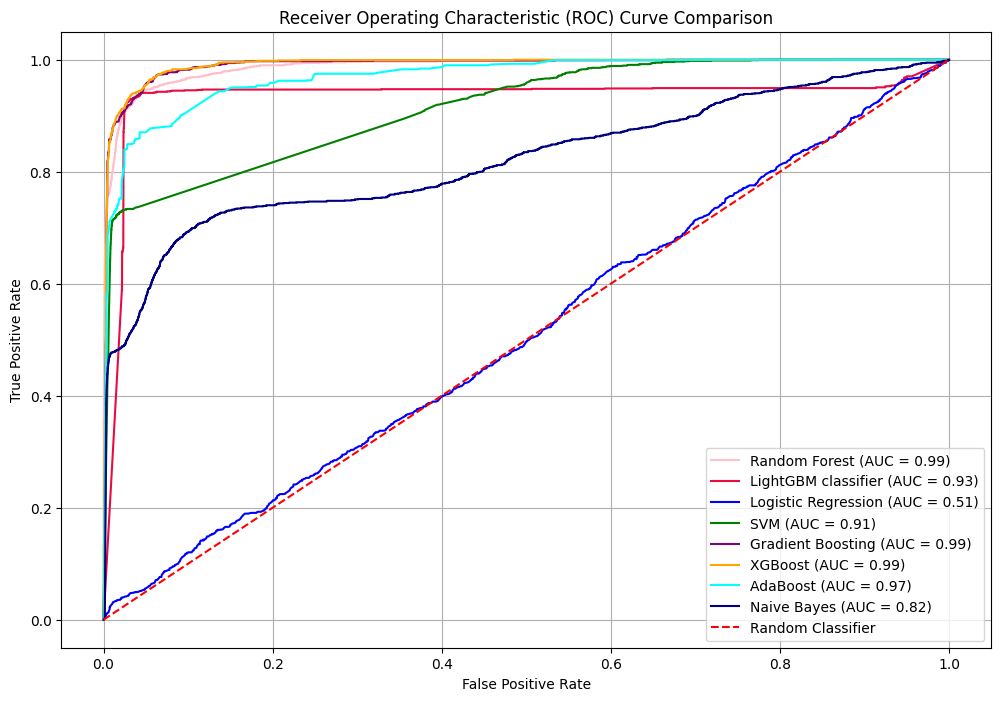

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# --- Plot all ROC curves on a single graph ---

plt.figure(figsize=(12, 8))
# Plot Random Forest Classifier
plt.plot(fpr_rf, tpr_rf, color='pink', label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
# Plot LightGBM Classifier
plt.plot(fpr_lgb, tpr_lgb, color=(234/255, 10/255, 66/255), label=f'LightGBM classifier (AUC = {roc_auc_lgb:.2f})')
# Plot Logistic Regression ROC
plt.plot(fpr_log_reg, tpr_log_reg, color='blue', label=f'Logistic Regression (AUC = {roc_auc_log_reg:.2f})')

# Plot SVM ROC (assuming fpr_svm, tpr_svm, roc_auc_svm are available from previous cells)
plt.plot(fpr_svm, tpr_svm, color='green', label=f'SVM (AUC = {roc_auc_svm:.2f})')

# Plot Gradient Boosting ROC (assuming fpr_gbc, tpr_gbc, roc_auc_gbc are available)
plt.plot(fpr_gbc, tpr_gbc, color='purple', label=f'Gradient Boosting (AUC = {roc_auc_gbc:.2f})')

# Plot XGBoost ROC (assuming fpr_xgb, tpr_xgb, roc_auc_xgb are available)
plt.plot(fpr_xgb, tpr_xgb, color='orange', label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')

# Plot AdaBoost ROC (assuming fpr_ada, tpr_ada, roc_auc_ada are available)
plt.plot(fpr_ada, tpr_ada, color='cyan', label=f'AdaBoost (AUC = {roc_auc_ada:.2f})')

# Plot Naive Bayes ROC (assuming fpr_nb, tpr_nb, roc_auc_nb are available)
plt.plot(fpr_nb, tpr_nb, color='navy', label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# List of models and their names
models = [
    ('Logistic Regression', log_reg_model, X_valid),
    ('SVM', svm_model, X_valid_scaled),
    ('Gradient Boosting', gbc_model, X_valid_scaled),
    ('XGBoost', xgb_model, X_valid_scaled),
    ('AdaBoost', ada_model, X_valid_scaled),
    ('Naive Bayes', nb_model, X_valid_scaled),
    ('Random Forest', rf_model, X_valid),
    ('LightGBM', lgb_model, X_valid)
]

# Calculate metrics for each model
results = []
for name, model, X in models:
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    # Print Confusion Matrix
    print(f"\nConfusion Matrix on Validation Set {name}:")
    conf_matrix = confusion_matrix(y_valid, y_pred)
    display(pd.DataFrame(conf_matrix,
                         index=['Actual 0', 'Actual 1'],
                         columns=['Predicted 0', 'Predicted 1']))
    print(f"====================================================")


Confusion Matrix on Validation Set Logistic Regression:


,Predicted 0,Predicted 1
Actual 0,257815,0
Actual 1,1520,0



Confusion Matrix on Validation Set SVM:


,Predicted 0,Predicted 1
Actual 0,257815,0
Actual 1,1520,0



Confusion Matrix on Validation Set Gradient Boosting:


...

,Predicted 0,Predicted 1
Actual 0,159508,98307
Actual 1,348,1172



Confusion Matrix on Validation Set Random Forest:


,Predicted 0,Predicted 1
Actual 0,254040,3775
Actual 1,232,1288



Confusion Matrix on Validation Set LightGBM:


,Predicted 0,Predicted 1
Actual 0,249324,8491
Actual 1,106,1414


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# List of models and their names
models = [
    ('Logistic Regression', log_reg_model, X_valid),
    ('SVM', svm_model, X_valid_scaled),
    ('Gradient Boosting', gbc_model, X_valid_scaled),
    ('XGBoost', xgb_model, X_valid_scaled),
    ('AdaBoost', ada_model, X_valid_scaled),
    ('Naive Bayes', nb_model, X_valid_scaled),
    ('Random Forest', rf_model, X_valid),
    ('LightGBM', lgb_model, X_valid)
]

# Calculate metrics for each model
results = []
for name, model, X in models:
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_valid, y_pred),
        'Precision': precision_score(y_valid, y_pred),
        'Recall': recall_score(y_valid, y_pred),
        'F1-Score': f1_score(y_valid, y_pred),
        'ROC AUC': roc_auc_score(y_valid, y_prob)
    })

# Create Comparison DataFrame
df_comparison = pd.DataFrame(results)

# Display the results sorted by ROC AUC
display(df_comparison.sort_values(by='Recall', ascending=False).reset_index(drop=True))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,XGBoost,0.958667,0.118836,0.943421,0.211084,0.991630
1,Gradient Boosting,0.962157,0.127403,0.932895,0.224190,0.990495
2,LightGBM,0.966850,0.142756,0.930263,0.247527,0.934637
3,AdaBoost,0.910448,0.055719,0.895395,0.104910,0.970396
4,Random Forest,0.984549,0.254395,0.847368,0.391311,0.987360
5,Naive Bayes,0.619585,0.011781,0.771053,0.023208,0.821773
6,Logistic Regression,0.994139,0.000000,0.000000,0.000000,0.508979
7,SVM,0.994139,0.000000,0.000000,0.000000,0.914597


Fine tuning of the choosen model - XGBoost

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

# Using y_pred_proba_xgb for the XGBoost model and y_valid for the actual labels
for threshold in np.arange(0.1, 1.0, 0.1):
    temp_preds = (y_pred_proba_xgb >= threshold).astype(int)
    p = precision_score(y_valid, temp_preds)
    r = recall_score(y_valid, temp_preds)
    print(f"Threshold: {threshold:.1f} | Precision: {p:.2f} | Recall: {r:.2f}")

Threshold: 0.1 | Precision: 0.03 | Recall: 1.00
Threshold: 0.2 | Precision: 0.04 | Recall: 0.99
Threshold: 0.3 | Precision: 0.05 | Recall: 0.98
Threshold: 0.4 | Precision: 0.09 | Recall: 0.97
Threshold: 0.5 | Precision: 0.12 | Recall: 0.94
Threshold: 0.6 | Precision: 0.19 | Recall: 0.91
Threshold: 0.7 | Precision: 0.32 | Recall: 0.88
Threshold: 0.8 | Precision: 0.38 | Recall: 0.86
Threshold: 0.9 | Precision: 0.49 | Recall: 0.82
